<a href="https://colab.research.google.com/github/YRMESHRAM/Machine-Vision-Practical/blob/main/MV_P6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
import kagglehub

# Ensure path is defined by re-downloading if necessary, or assuming it was previously defined.
# For robustness, we'll re-download it here if 'path' is not already in the global scope.
try:
    path
except NameError:
    print("Path variable not found, re-downloading dataset.")
    path = kagglehub.dataset_download("msambare/fer2013")
    print("Path to dataset files:", path)

# List the contents of the downloaded path
print("Contents of the dataset directory:")
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 4 * (level)
    print(f'{indent}{os.path.basename(root)}/')
    subindent = ' ' * 4 * (level + 1)
    for f in files:
        print(f'{subindent}{f}')
    if level > 2: # Limit depth to avoid too much output
        break

Streaming output truncated to the last 5000 lines.
            Training_71717074.jpg
            Training_83349364.jpg
            Training_8224205.jpg
            Training_69103613.jpg
            Training_7098848.jpg
            Training_38129729.jpg
            Training_95151390.jpg
            Training_66874071.jpg
            Training_23294249.jpg
            Training_86508875.jpg
            Training_50691325.jpg
            Training_26593901.jpg
            Training_81451115.jpg
            Training_39982194.jpg
            Training_18980574.jpg
            Training_39446205.jpg
            Training_9457008.jpg
            Training_6020903.jpg
            Training_21992204.jpg
            Training_92578622.jpg
            Training_61529099.jpg
            Training_67326933.jpg
            Training_39457045.jpg
            Training_4433687.jpg
            Training_39160872.jpg
            Training_66460314.jpg
            Training_80567356.jpg
            Training_83239385.jpg
  

In [3]:
import tensorflow as tf

# Define image size and batch size
IMG_HEIGHT = 48
IMG_WIDTH = 48
BATCH_SIZE = 32

# Construct paths to train and test directories
train_dir = os.path.join(path, 'train')
test_dir = os.path.join(path, 'test') # Assuming 'test' is used for validation as per kaggle fer2013 structure

# Load training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Load validation dataset (using the 'test' directory as a validation set)
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    interpolation='nearest',
    batch_size=BATCH_SIZE,
    shuffle=False # No need to shuffle validation data
)

# Get class names
class_names = train_ds.class_names
print(f"Class names: {class_names}")

# Print number of batches
print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(val_ds).numpy()}")


Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.
Class names: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Number of training batches: 898
Number of validation batches: 225


In [4]:
# Normalize pixel values to be between 0 and 1
def normalize_img(image, label):
    return tf.cast(image, tf.float32) / 255., label

train_ds = train_ds.map(normalize_img)
val_ds = val_ds.map(normalize_img)

# Optimize dataset for performance
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Datasets preprocessed and optimized.")

Datasets preprocessed and optimized.


In [7]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model

# Load the pre-trained MobileNetV2 model without the top classification layer
base_model = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
                         include_top=False,
                         weights='imagenet')

# Freeze the base model to prevent its weights from being updated during training
base_model.trainable = False

# Add custom classification layers on top of the base model
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
predictions = layers.Dense(len(class_names), activation='softmax')(x)

# Create the new model
pretrained_model = Model(inputs=base_model.input, outputs=predictions)

# Compile the new model
pretrained_model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

# Print the summary of the new model
pretrained_model.summary()

/tmp/ipykernel_2608/2967609508.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 48, 48, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 24, 24,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 24, 24,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 24, 24,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 24, 24,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 24, 24,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 24, 24,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 24, 24,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 24, 24,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 24, 24,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 24, 24,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 24, 24,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 25, 25,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 12, 12,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 12, 12,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 12, 12,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 12, 12,    │      2,304 │ block_1_depthwis

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [8]:
EPOCHS = 10 # We can adjust this number based on performance

history_pretrained = pretrained_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

print("Pre-trained model training complete.")

Epoch 1/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 85s 88ms/step - accuracy: 0.3558 - loss: 1.6415 - val_accuracy: 0.3840 - val_loss: 1.5827
Epoch 2/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 81s 87ms/step - accuracy: 0.4206 - loss: 1.4974 - val_accuracy: 0.3957 - val_loss: 1.5497
Epoch 3/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 78s 86ms/step - accuracy: 0.4716 - loss: 1.3853 - val_accuracy: 0.3965 - val_loss: 1.5516
Epoch 4/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 76s 85ms/step - accuracy: 0.5262 - loss: 1.2654 - val_accuracy: 0.3977 - val_loss: 1.5719
Epoch 5/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 78s 87ms/step - accuracy: 0.5791 - loss: 1.1416 - val_accuracy: 0.3945 - val_loss: 1.6351
Epoch 6/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 78s 87ms/step - accuracy: 0.6281 - loss: 1.0222 - val_accuracy: 0.3933 - val_loss: 1.7053
Epoch 7/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 78s 87ms/step - accuracy: 0.6741 - loss: 0.9117 - val_accuracy: 0.3909 - val_loss: 1.7823
Epoch 8/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 82s 87ms/step - accuracy: 0.7147 - loss: 0.8089 - 

225/225 ━━━━━━━━━━━━━━━━━━━━ 16s 71ms/step - accuracy: 0.3927 - loss: 2.1569
Validation Loss: 2.1569
Validation Accuracy: 0.3927


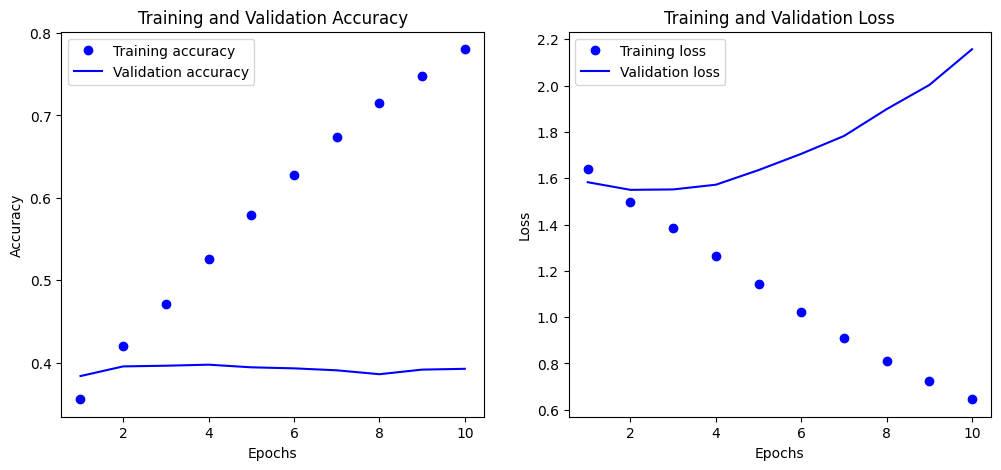

In [9]:
import matplotlib.pyplot as plt

# Evaluate the model on the validation set
loss, accuracy = pretrained_model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

# Plot training history
history_dict = history_pretrained.history
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
loss = history_dict['loss']
val_loss = history_dict['val_loss']

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


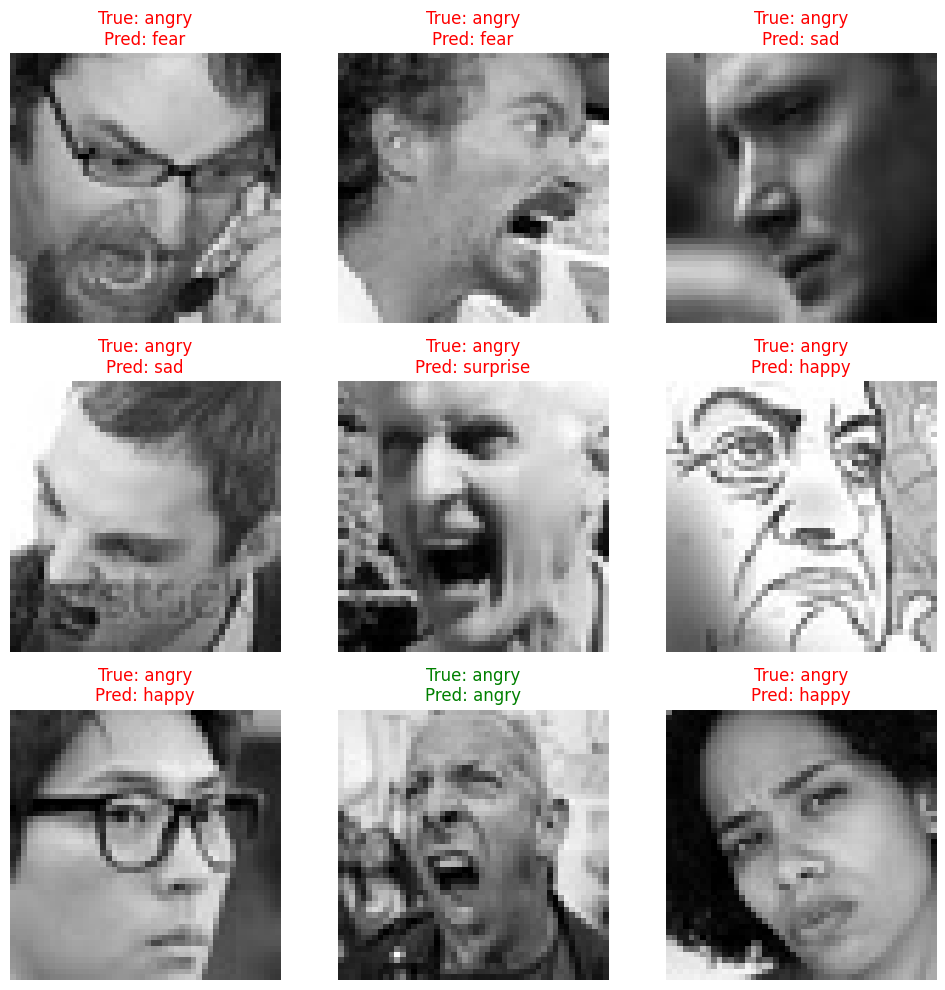

In [10]:
import numpy as np

# Get a batch of validation data
for images, labels in val_ds.take(1):
    break

# Make predictions
predictions = pretrained_model.predict(images)

plt.figure(figsize=(10, 10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy())

    predicted_class = np.argmax(predictions[i])
    true_class = labels[i].numpy()

    title_color = "green" if predicted_class == true_class else "red"

    plt.title(f"True: {class_names[true_class]}\nPred: {class_names[predicted_class]}", color=title_color)
    plt.axis("off")

plt.tight_layout()
plt.show()